Thirupathi Kadari<br>
Kiran Sai Vutukuri

# Introduction 

This assignment involves migrating data from a PostgreSQL database to a Neo4j database and then querying specific data using Neo4j's Cypher query language. The data from the Artist, Album, Track, Genre, and MediaType tables of the PostgreSQL Chinook database are exported to CSV files, which are then loaded into a Neo4j database. Afterward, we construct and execute queries to retrieve desired Chinook content from the Neo4j graph database.

To begin, the required data is exported from Postgres to CSV files. Then, we create an appropriate schema for the Neo4j database to effectively manage and organize the Chinook data. Next, we construct Cypher commands to implement the graph database schema as we load the Chinook data from the CSV files obtained from Postgres into a new Neo4j database. Finally, we use our expertise in Neo4j data retrieval to construct a set of Cypher queries to retrieve specific Chinook content from within the Neo4j graph database.

# Migration From PostgreSQL to Neo4j  

## Postgres to CSV

we have used COPY statement for exporting data of a table to a CSV file. we export the content of each of the Artist, Album, Track, Genre and MediaType tables from Postgres to a separate Artist.csv, Album.csv, Track.csv, Genre.csv, MediaType.csv files.

Commands:

COPY "Artist" TO 'C:\Users\thiru\Downloads\M13\Artist.csv' DELIMITER ',' CSV HEADER;

COPY "Album" TO 'C:\Users\thiru\Downloads\M13\Album.csv' DELIMITER ',' CSV HEADER;

COPY "Track" TO 'C:\Users\thiru\Downloads\M13\Track.csv' DELIMITER ',' CSV HEADER;

COPY "Genre" TO 'C:\Users\thiru\Downloads\M13\Genre.csv' DELIMITER ',' CSV HEADER;

COPY "MediaType" TO 'C:\Users\thiru\Downloads\M13\Media.csv' DELIMITER ',' CSV HEADER;

## Graph database schema

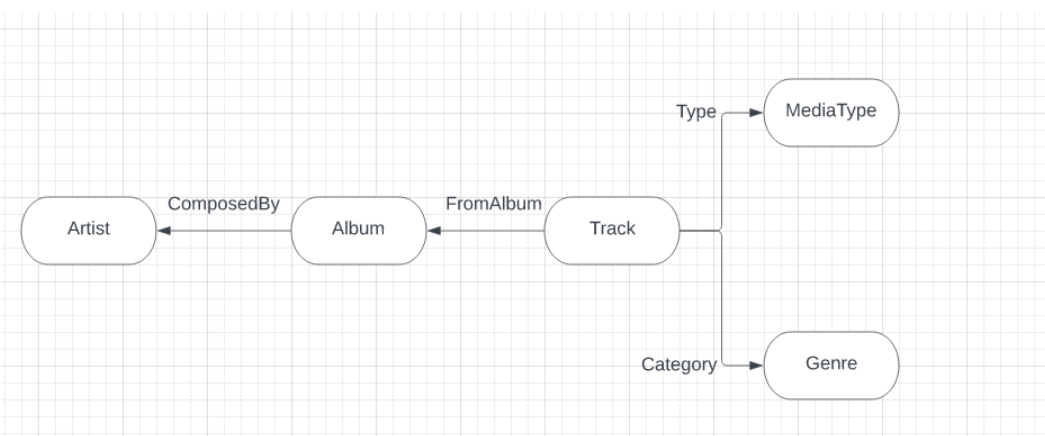

When deriving a graph model from a relational model.

1. A row becomes a node.

2. A table name becomes a label name.

3. A join or foreign key becomes a relationship.

**Rows to Nodes, Table names to labels**<br>
- Each row on our Artist table becomes a node in our graph with Artist as the label.
- Each row on our Album table becomes a node in our graph with Album as the label.
- Each row on our Track table becomes a node in our graph with Track as the label.
- Each row on our Genre table becomes a node in our graph with Genre as the label.
- Each row on our Media Type table becomes a node in our graph with Media Type as the label.

**Joins to relationships**
- Join between Artist and Album becomes a relationship named ComposedBy (where every album has a artist).

- Join between Album and Track becomes a relationship named FromAlbum (where Track is part of a Album).

- Join between Track and Mediatype becomes a relationship named type (where every track has its respective mediatype).

- Join between Track and Genre becomes a relationship named Category (where every track has like rock jazz etc..).

## Implementation

### Load

I have uploded the above csv files to my Github repository. Then we used Cypher’s LOAD CSV statement to read each file and add Cypher clauses after it to take the row/column data and transform it to the graph.

**Artist node:**

LOAD CSV WITH HEADERS FROM 'https://raw.githubusercontent.com/Thirupathi-Kadari/Data-Aq-Management/main/Artist.csv' AS row MERGE (artist:Artist {ArtistId: row.ArtistId}) ON CREATE SET artist.Name = row.Name;

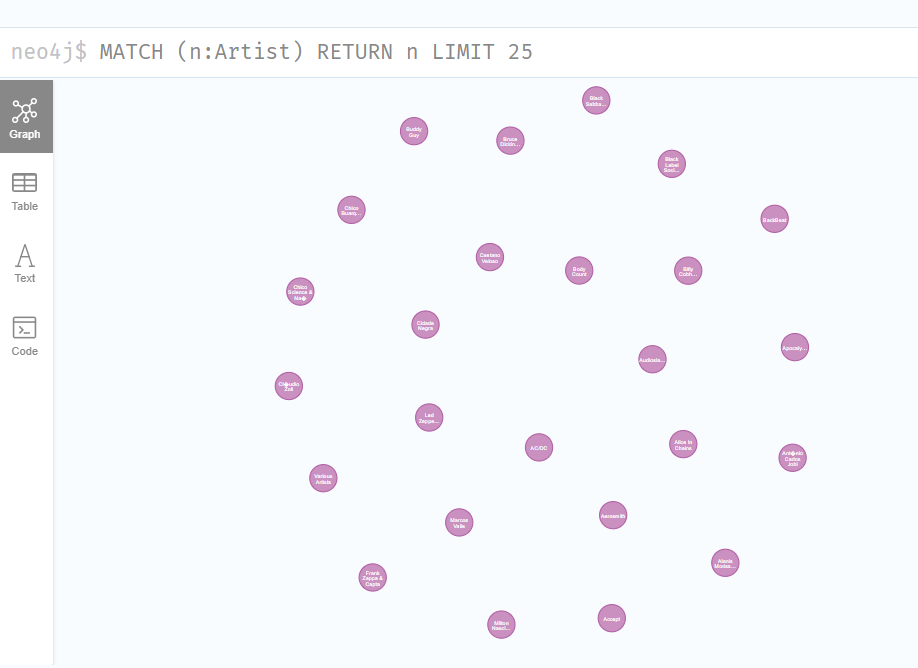

**Album node:**

LOAD CSV WITH HEADERS FROM 'https://raw.githubusercontent.com/Thirupathi-Kadari/Data-Aq-Management/main/Album.csv' AS row
MERGE (album:Album {AlbumId: row.AlbumId})
ON CREATE SET album.Title = row.Title;

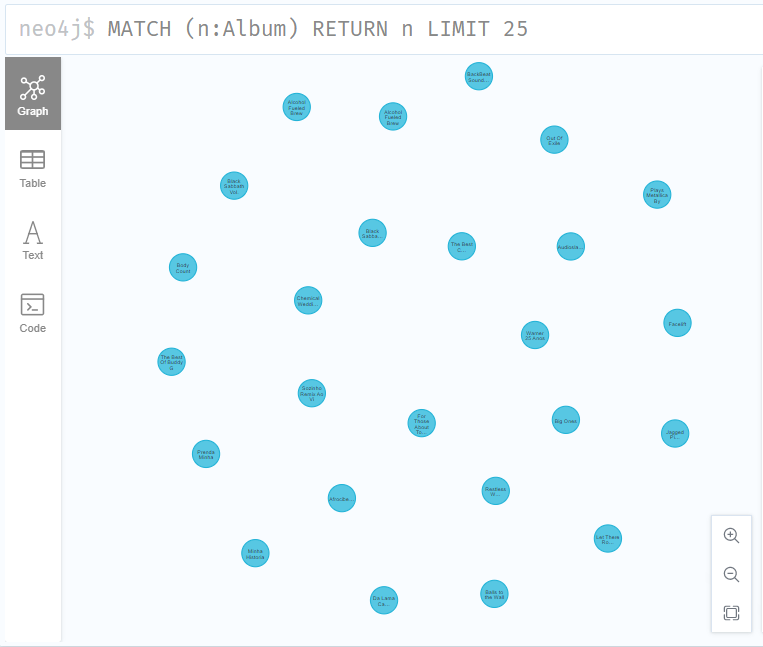

**Track node:**

LOAD CSV WITH HEADERS FROM 'https://raw.githubusercontent.com/Thirupathi-Kadari/Data-Aq-Management/main/Track.csv' AS row
MERGE (track:Track {TrackId: row.TrackId}) ON CREATE SET track.Name = row.Name, track.Composer = row.Composer, track.MilliSec = toFloat(row.Milliseconds),track.Bytes = toInteger(row.Bytes),track.UnitPrice = toFloat(row.UnitPrice) ;


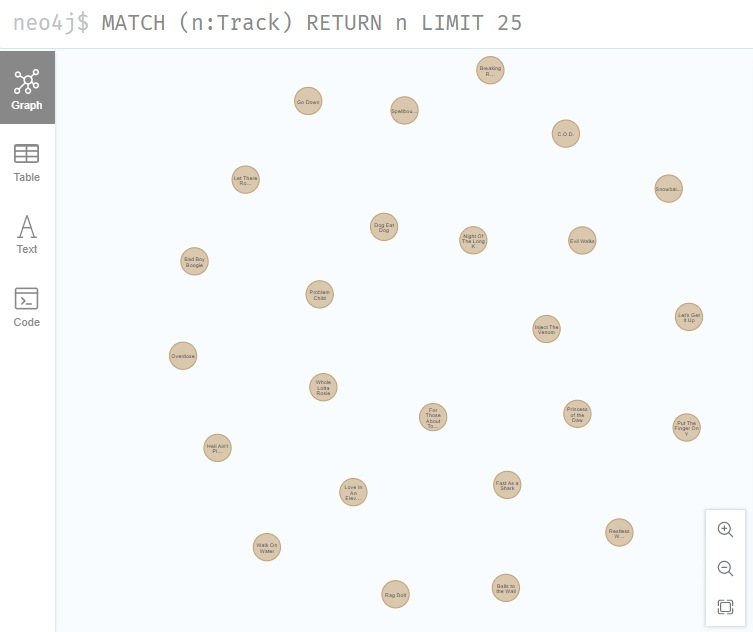

**Genre node:**

LOAD CSV WITH HEADERS FROM 'https://raw.githubusercontent.com/Thirupathi-Kadari/Data-Aq-Management/main/Genre.csv' AS row MERGE (genre:Genre {GenreId: row.GenreId}) ON CREATE SET genre.Name = row.Name;

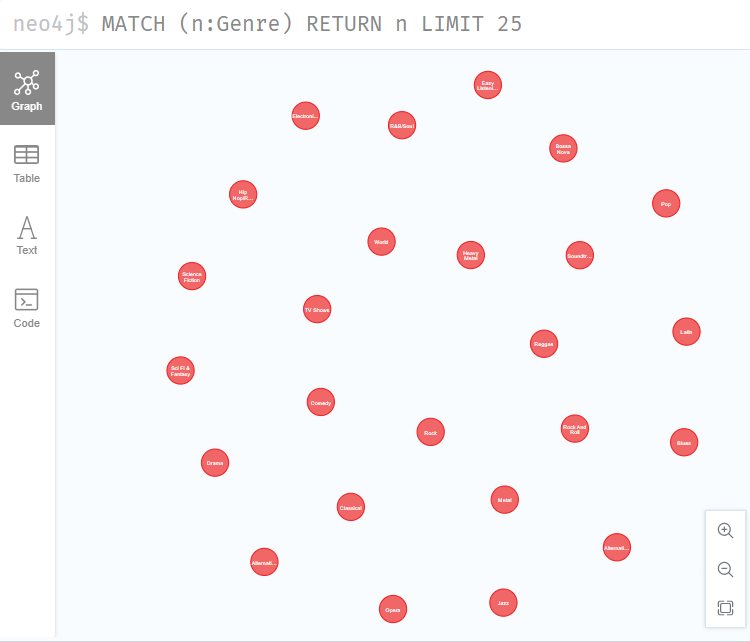


**MediaType node:**

LOAD CSV WITH HEADERS FROM 'https://raw.githubusercontent.com/Thirupathi-Kadari/Data-Aq-Management/main/Media.csv' AS row MERGE (mediatype:MediaType {MediaTypeId: row.MediaTypeId}) ON CREATE SET mediatype.Name = row.Name;


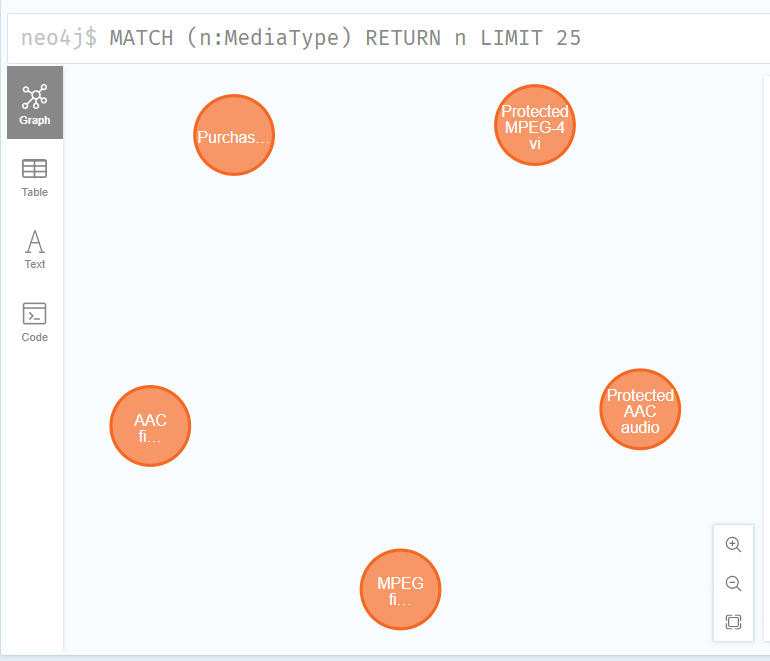

### Indexing

To ensure the lookup of nodes is optimized, we created indexes for any node properties used in the lookups (often the id or another unique value).

CREATE INDEX artist_id FOR (a:Artist) ON (a.ArtistId);

CREATE INDEX album_id FOR (al:Album) ON (al.AlbumId);

CREATE INDEX track_id FOR (t:Track) ON (t.TrackId);

CREATE INDEX genre_id FOR (g:Genre) ON (g.GenreId);

CREATE INDEX mediatype_id FOR (m:MediaType) ON (m.MediaTypeId);

### Relationships

If there are no relationships in a graph database, the nodes will be disconnected and won't have much value. By adding relationships between nodes, we provide context and meaning to the data in the database, allowing us to run complex queries across various parts of the graph.

#### Album-Artist

LOAD CSV WITH HEADERS FROM 'https://raw.githubusercontent.com/Thirupathi-Kadari/Data-Aq-Management/main/Album.csv' as row MATCH (album:Album {AlbumId: row.AlbumId}) MATCH (artist:Artist {ArtistId: row.ArtistId}) MERGE (album)-[aa:ComposedBy]->(artist); MATCH (al:Album)-[]-(ar:Artist) RETURN al,ar LIMIT 10;

#### Track-Album

LOAD CSV WITH HEADERS FROM 'https://raw.githubusercontent.com/Thirupathi-Kadari/Data-Aq-Management/main/Track.csv' as row
MATCH (track:Track {TrackId: row.TrackId})
MATCH (album:Album {AlbumId: row.AlbumId})
MERGE (track)-[ta:FromAlbum]->(album);

MATCH (t:Track)-[]-(a:Album) RETURN t,a LIMIT 10;

#### Track-MediaType

LOAD CSV WITH HEADERS FROM 'https://raw.githubusercontent.com/Thirupathi-Kadari/Data-Aq-Management/main/Track.csv' as row
MATCH (track:Track {TrackId: row.TrackId})
MATCH (mediatype:MediaType {MediaTypeId: row.MediaTypeId})
MERGE (track)-[tm:type]->(mediatype);

MATCH (t:Track)-[]-(m:MediaType)
RETURN t,m LIMIT 10;

#### Track-Genre

LOAD CSV WITH HEADERS FROM 'https://raw.githubusercontent.com/Thirupathi-Kadari/Data-Aq-Management/main/Track.csv' as row
MATCH (track:Track {TrackId: row.TrackId})
MATCH (genre:Genre {GenreId: row.GenreId})
MERGE (track)-[tg:category]->(genre);

MATCH (t:Track)-[]-(g:Genre)
RETURN t,g LIMIT 10;

**Comment**<br>
The visual graph navigation in Neo4j Browser behaved as I anticipated, allowing me to zoom in and out, drag and drop nodes, and filter nodes and relationships. Overall, the visual graph navigation provided a useful way to explore and analyze the relationships between Artist, Album, Track, Genre and Media Type in the Chinook database.

# Using Cypher to Retrieve Data from Neo4j

## (a) Write and execute a Cypher query that returns all Tracks from the ‘Jazz’ genre composed by ‘Miles Davis’ 

MATCH (t:Track)-[category]->(g:Genre)

WHERE g.Name = "Jazz"

AND EXISTS {
  
        MATCH (t)-[FromAlbum]->(a:Album)-[ComposedBy]->(ar:Artist)
        WHERE ar.Name = "Miles Davis"
        }
 RETURN t;

This Cypher query looks for all tracks that belong to the 'Jazz' genre and are composed by the artist 'Miles Davis'. The query first matches all tracks that have a relationship with a genre node and then narrows down the search to only those tracks that have a relationship with an album node composed by 'Miles Davis'. Finally, it returns the resulting tracks.

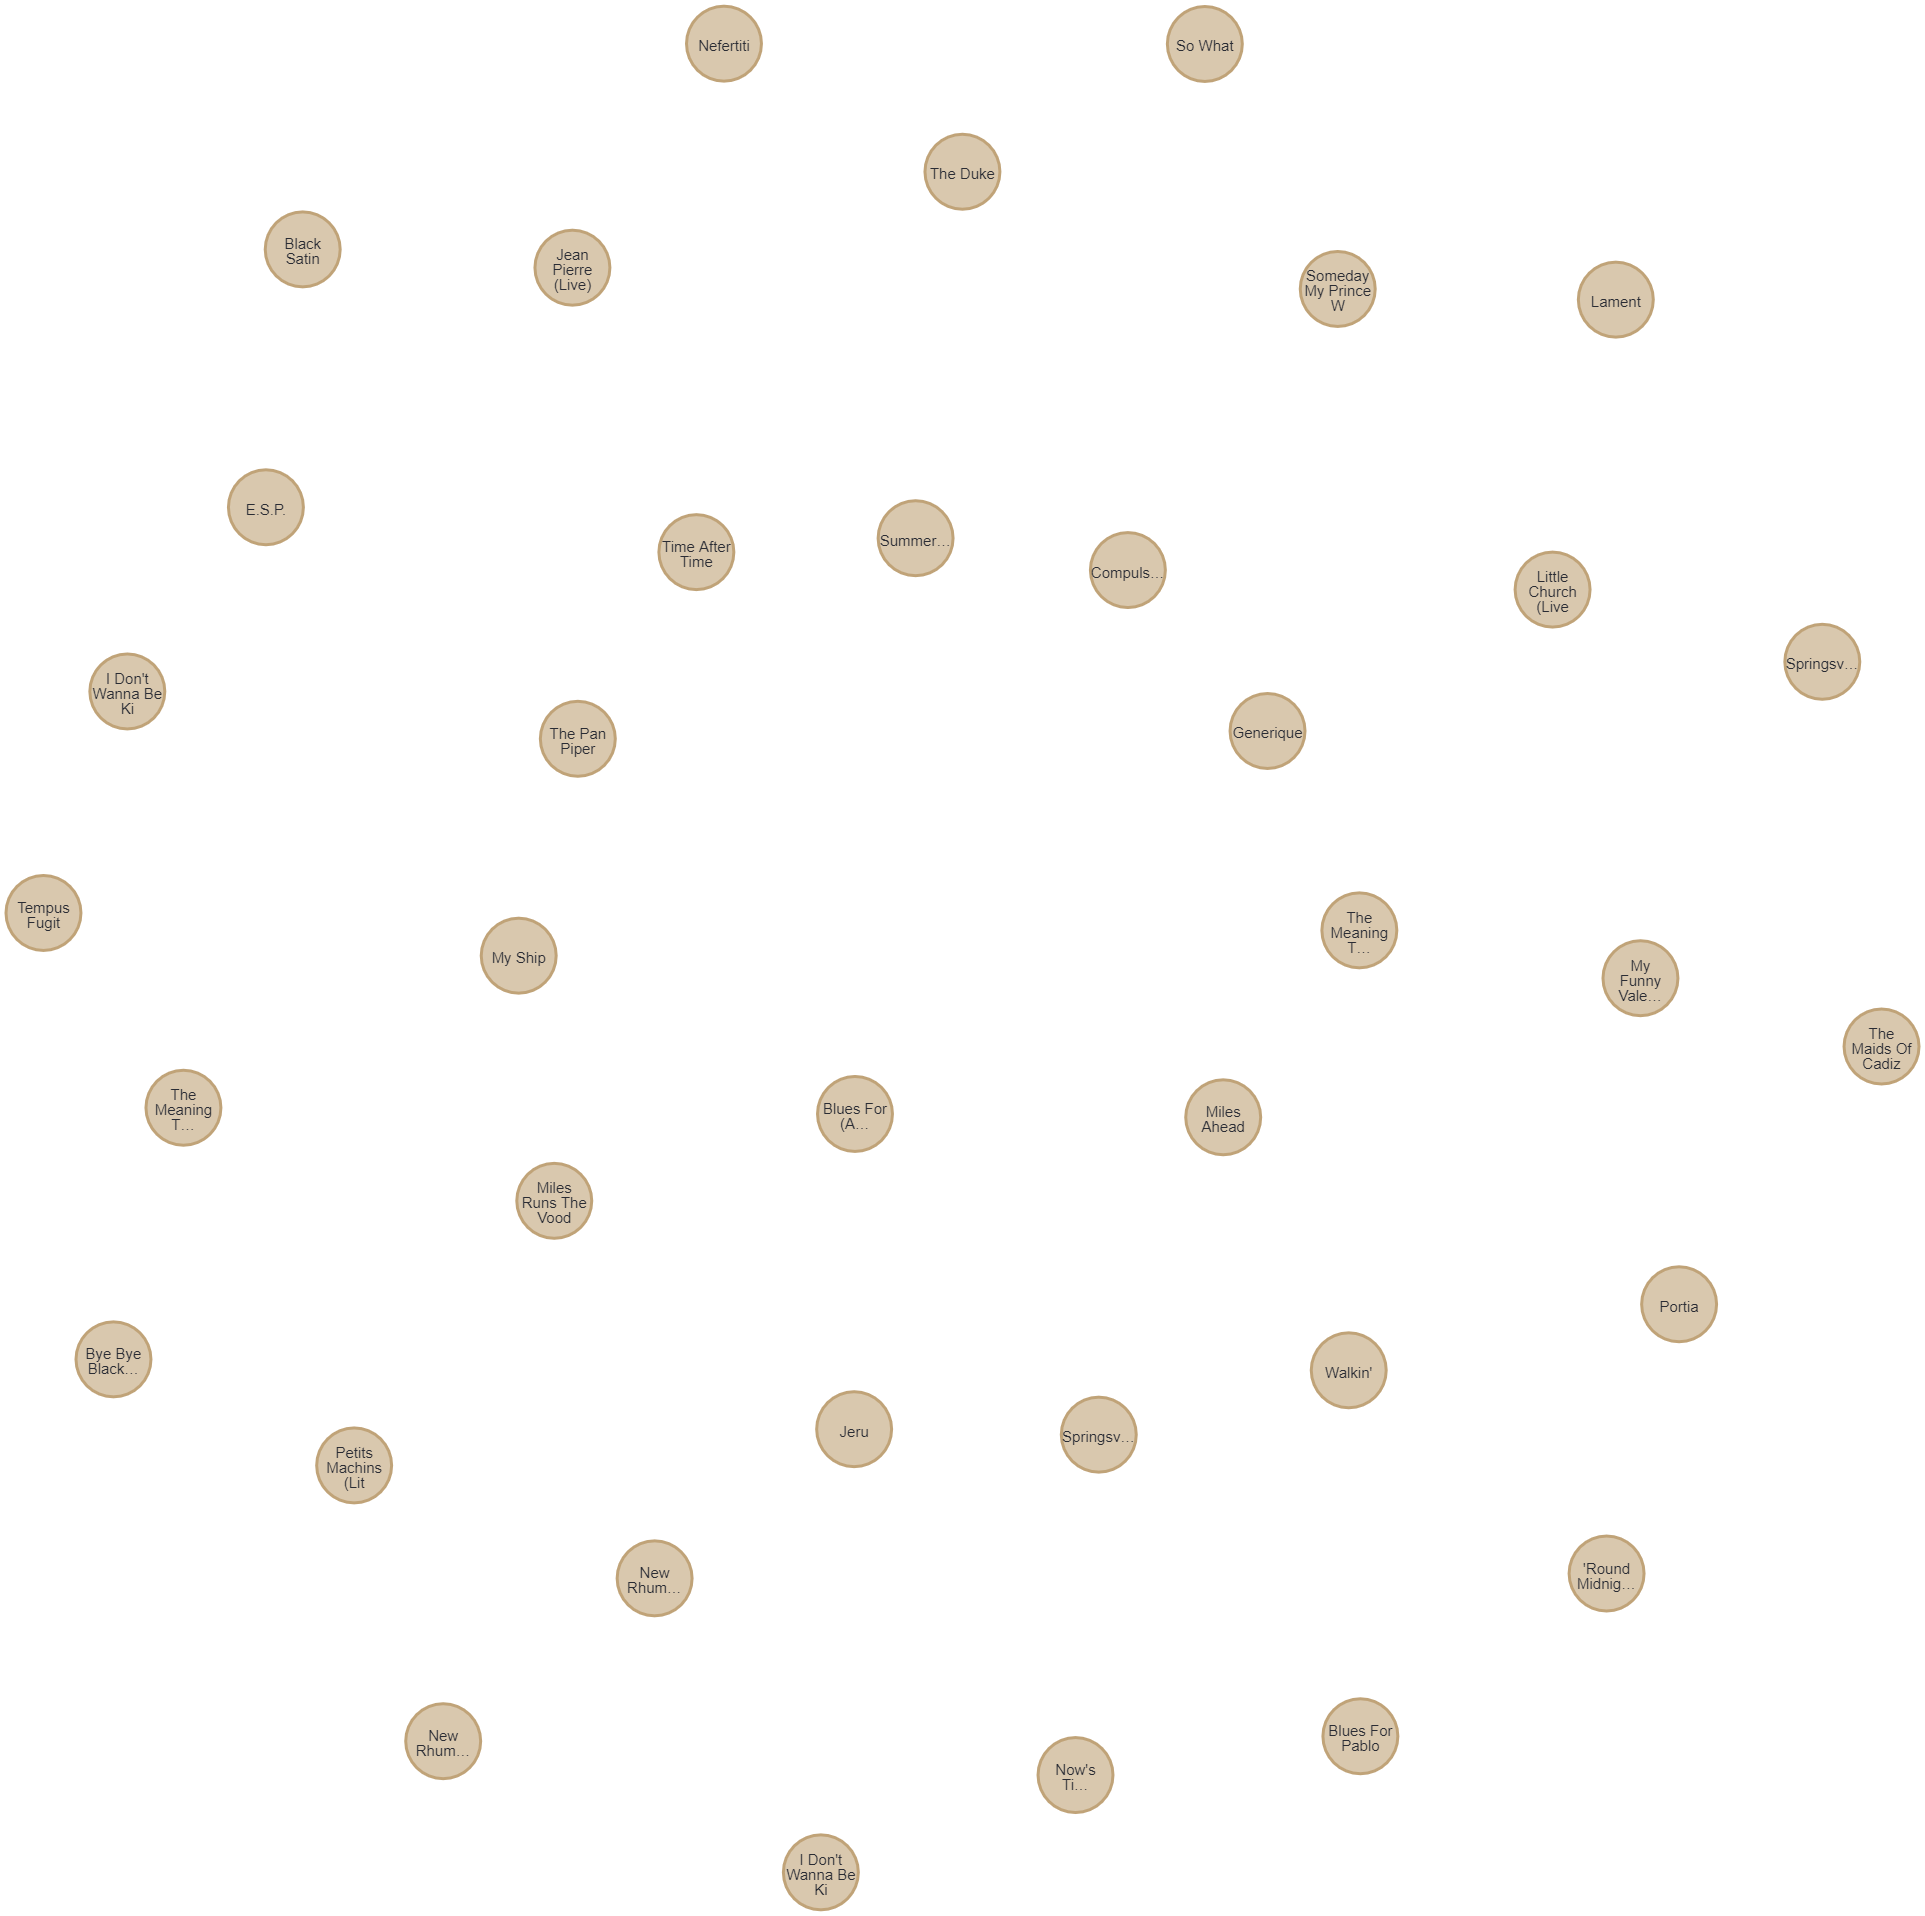

## (b) Write and execute a Cypher query that returns all Artists that have any Tracks available in the ‘AAC audio file’ media type. 

MATCH (ar:Artist)<-[ComposedBy]-(al:Album)<-[FromAlbum]-(t:Track)-[type]->(mt:MediaType)

WHERE mt.Name = "AAC audio file"

RETURN ar.Name;

This query retrieves the names of all artists whose tracks are in albums that were encoded in AAC audio format. The query starts by matching the artist, album, track and media type nodes using their respective labels and relationships. The WHERE clause filters the results to only include those tracks that belong to albums with the media type "AAC audio file". Finally, the RETURN statement selects the name property of the artist nodes that match the criteria.

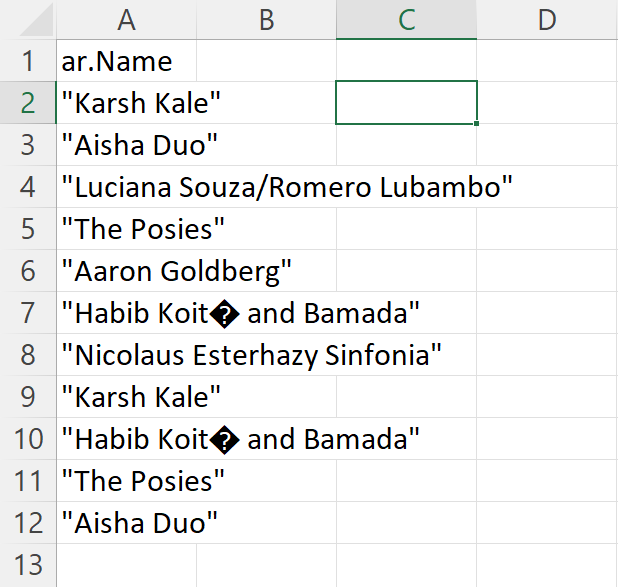

In the above I have provided the Screen Shot of output csv file that has downloded from the output of the above Cypher query.

## (c) Write and execute a Cypher query that returns the Artist associated with the album ‘Bongo Fury’.   

MATCH (ar:Artist)<-[ComposedBy]-(al:Album)

WHERE al.Title = "Bongo Fury"

RETURN ar.Name;

This query begins by matching the Artist nodes connected to the Album node with a ComposedBy relationship where the album title is "Bongo Fury". It then returns the name of the Artist node that was matched. It starts with the Artist and Album nodes, then narrows down the results by specifying the album title before returning the Artist name.

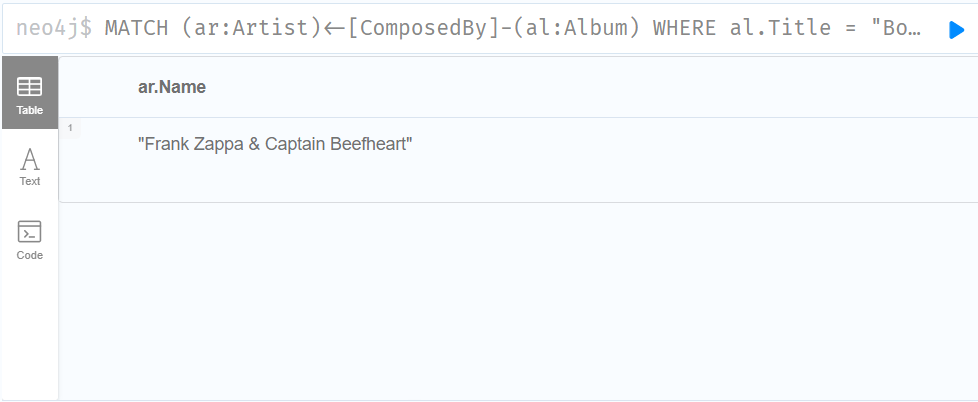

## (d) Write and execute a Cypher query that returns all Tracks from the album ‘Coda’ by the artist ‘Led Zeppelin’.

MATCH (ar:Artist)<-[ComposedBy]-(al:Album)<-[FromAlbum]-(t:Track)

WHERE al.Title = "Coda" AND ar.Name = "Led Zeppelin"

RETURN t;

This query looks for tracks that are in the "Coda" album and were composed by the "Led Zeppelin" artist. It does this by first matching the artist and album nodes connected through a "ComposedBy" relationship, and then matching tracks connected through a "FromAlbum" relationship to the album. The query then filters the results by checking that the album title is "Coda" and the artist name is "Led Zeppelin", and returns the corresponding tracks.

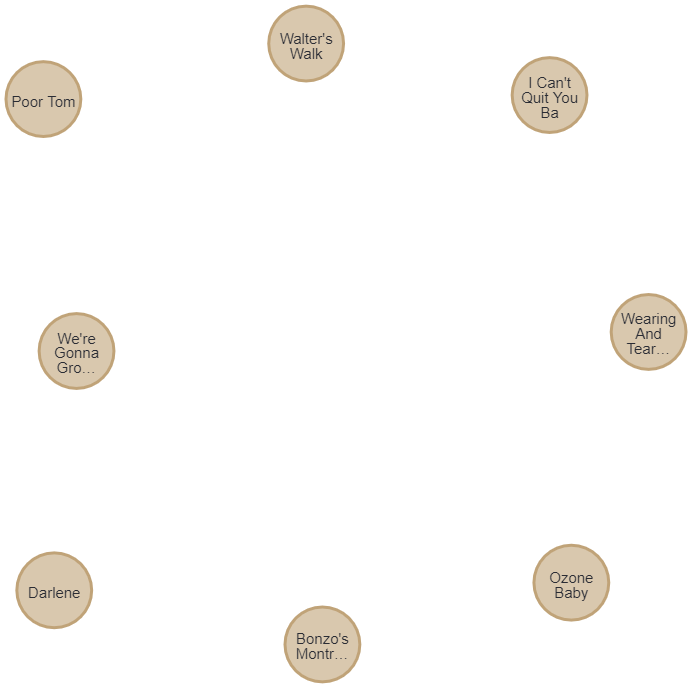

## (e) Write and execute a Cypher query that returns all Albums that contain Tracks composed by ‘Alanis Morissette & Glenn Ballard’ 

MATCH (al:Album)<-[FromAlbum]-(t:Track)

WHERE t.Composer = "Alanis Morissette & Glenn Ballard"

RETURN al;

The query starts by matching all tracks (t) and their associated albums (al) through the "FromAlbum" relationship. It then filters the results to only include albums where at least one track has the composer "Alanis Morissette & Glenn Ballard", and returns those albums. The Composer property is likely stored as a property of the Track nodes, hence the filtering on the Track nodes in the query.

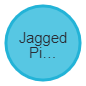

## (f) Write and execute a Cypher query that returns the names of all Albums containing Tracks for which no Composer has been specified. 

MATCH (al:Album)<-[FromAlbum]-(t:Track)

WHERE t.Composer IS NULL

RETURN t;

The query uses the MATCH keyword to match all Tracks with their corresponding Albums. It then filters the results to only include Tracks where no Composer has been specified using the WHERE keyword with the IS NULL condition. Finally, the query returns the Album nodes that are connected to these Tracks via the FromAlbum relationship.

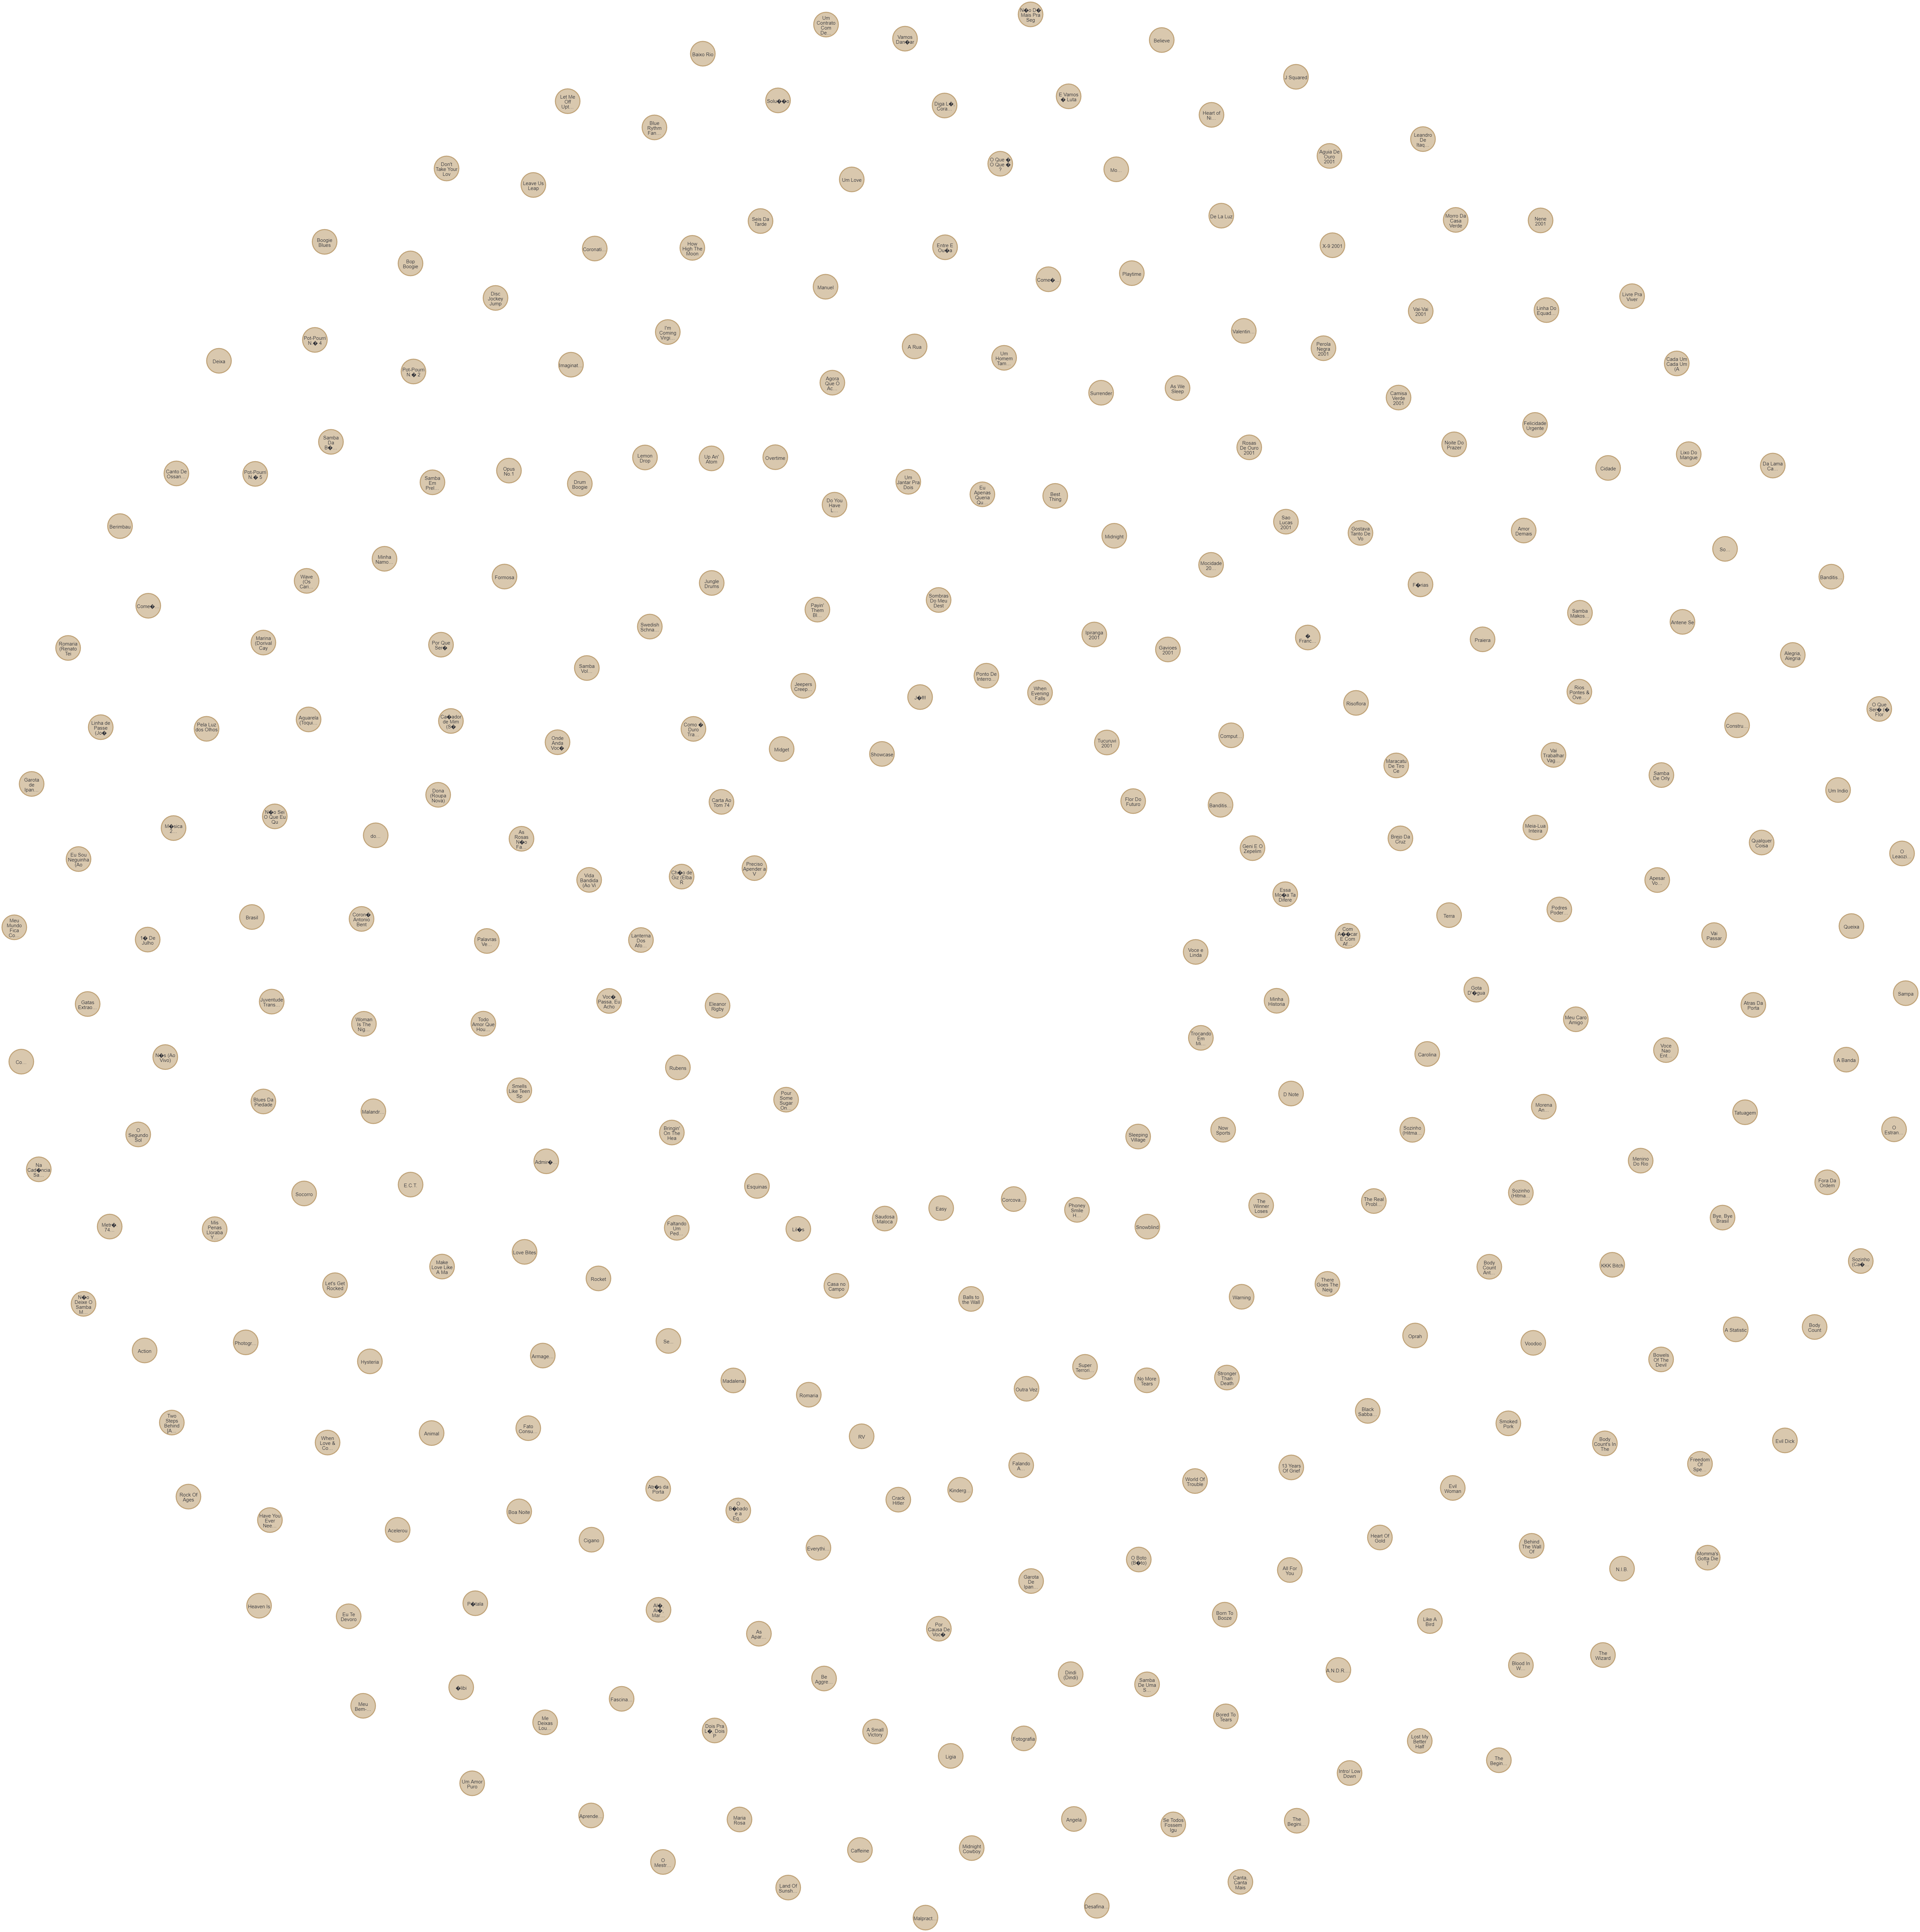